# Metro Interstate Traffic Volume — EDA & Preprocessing

**Notebook 1 of 2**

This notebook prepares the Metro Interstate Traffic Volume dataset for modeling. It covers:

1. Data loading and initial inspection
2. Data cleaning (missing values, duplicates, invalid readings)
3. Exploratory Data Analysis (EDA)
4. Feature engineering from the `date_time` column
5. Encoding of categorical features
6. Export of a cleaned, model-ready dataset

The output of this notebook (`data/traffic_processed.csv`) is consumed directly by `02_Model_Training.ipynb`.


## 1. Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)


## 2. Load Dataset

In [7]:
RAW_DATA_PATH = "data/Traffic_Volume.csv"

df = pd.read_csv(RAW_DATA_PATH)
print(f"Shape: {df.shape}")
df.head()


Shape: (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [9]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
holiday,61,11,Labor Day,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temp,48204.0,NaN,NaN,NaN,281.20587,13.338232,0.0,272.16,282.45,291.806,310.07
rain_1h,48204.0,NaN,NaN,NaN,0.334264,44.789133,0.0,0.0,0.0,0.0,9831.3
snow_1h,48204.0,NaN,NaN,NaN,0.000222,0.008168,0.0,0.0,0.0,0.0,0.51
clouds_all,48204.0,NaN,NaN,NaN,49.362231,39.01575,0.0,1.0,64.0,90.0,100.0
weather_main,48204,11,Clouds,15164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather_description,48204,38,sky is clear,11665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_time,48204,40575,2013-05-19 10:00:00,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
traffic_volume,48204.0,NaN,NaN,NaN,3259.818355,1986.86067,0.0,1193.0,3380.0,4933.0,7280.0


## 3. Data Cleaning

The raw dataset has several known data quality issues that must be handled before modeling:

- `holiday` is almost entirely the literal string `"None"`, which pandas already parses as `NaN`. This is expected — the dataset only tags the single hour a holiday begins.
- `date_time` contains duplicate timestamps (repeated hourly weather readings).
- `rain_1h` contains an extreme outlier (~9831 mm in one hour), which is a known data entry error.
- `temp` contains a small number of `0` Kelvin readings, which is physically impossible (absolute zero) and indicates a sensor/logging error.


### 3.1 Data types

In [10]:
df["date_time"] = pd.to_datetime(df["date_time"])
df.dtypes


holiday                        object
temp                          float64
rain_1h                       float64
snow_1h                       float64
clouds_all                      int64
weather_main                   object
weather_description            object
date_time              datetime64[ns]
traffic_volume                  int64
dtype: object

### 3.2 Missing values

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct.round(2)})


,missing_count,missing_pct
holiday,48143,99.87
temp,0,0.00
rain_1h,0,0.00
snow_1h,0,0.00
clouds_all,0,0.00
weather_main,0,0.00
weather_description,0,0.00
date_time,0,0.00
traffic_volume,0,0.00


In [12]:
# `holiday` is NaN for every regular (non-holiday) hour by design.
# We convert it into a clean categorical flag rather than dropping the column,
# since holidays are known to affect traffic patterns.
df["holiday"] = df["holiday"].fillna("None")
df["is_holiday"] = (df["holiday"] != "None").astype(int)

df[["holiday", "is_holiday"]].head()


,holiday,is_holiday
0,None,0
1,None,0
2,None,0
3,None,0
4,None,0


### 3.3 Duplicate records

The dataset contains duplicate `date_time` entries where the same hour was logged more than once
(sometimes with different weather descriptions for the same hour). We keep the first occurrence
for each timestamp, then drop any fully duplicated rows.


In [13]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")
print(f"Duplicated timestamps: {df['date_time'].duplicated().sum()}")

# Drop exact duplicate rows first
df = df.drop_duplicates()

# For repeated timestamps, keep the first logged reading
df = df.sort_values("date_time").drop_duplicates(subset="date_time", keep="first")

df = df.reset_index(drop=True)
print(f"Shape after de-duplication: {df.shape}")


Fully duplicated rows: 17
Duplicated timestamps: 7629
Shape after de-duplication: (40575, 10)


### 3.4 Invalid sensor readings

- `temp` of 0 Kelvin is not physically possible for a weather station and is treated as a missing/invalid reading.
  We replace these with `NaN` and impute using the median temperature for the same month, which preserves seasonality.
- `rain_1h` has a single extreme outlier (~9831 mm/hour) that is orders of magnitude beyond any realistic hourly
  rainfall. We cap `rain_1h` at the 99.9th percentile to remove this data entry error while preserving genuine
  heavy-rain signal.


In [14]:
# Fix invalid temperature readings (0 K is impossible)
invalid_temp_count = (df["temp"] == 0).sum()
print(f"Invalid temp (0 K) readings: {invalid_temp_count}")

df["temp"] = df["temp"].replace(0, np.nan)
df["month_tmp"] = df["date_time"].dt.month
df["temp"] = df.groupby("month_tmp")["temp"].transform(lambda x: x.fillna(x.median()))
df = df.drop(columns=["month_tmp"])

print(f"Remaining missing temp values: {df['temp'].isnull().sum()}")


Invalid temp (0 K) readings: 10
Remaining missing temp values: 0


In [15]:
# Cap the rain_1h outlier
rain_cap = df["rain_1h"].quantile(0.999)
print(f"Rain_1h 99.9th percentile cap: {rain_cap:.2f} mm")

outlier_count = (df["rain_1h"] > rain_cap).sum()
print(f"Rows capped: {outlier_count}")

df["rain_1h"] = np.where(df["rain_1h"] > rain_cap, rain_cap, df["rain_1h"])
df["rain_1h"].describe()


Rain_1h 99.9th percentile cap: 10.10 mm
Rows capped: 41


count    40575.000000
mean         0.068791
std          0.540188
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         10.096860
Name: rain_1h, dtype: float64

## 4. Exploratory Data Analysis

### 4.1 Traffic volume distribution

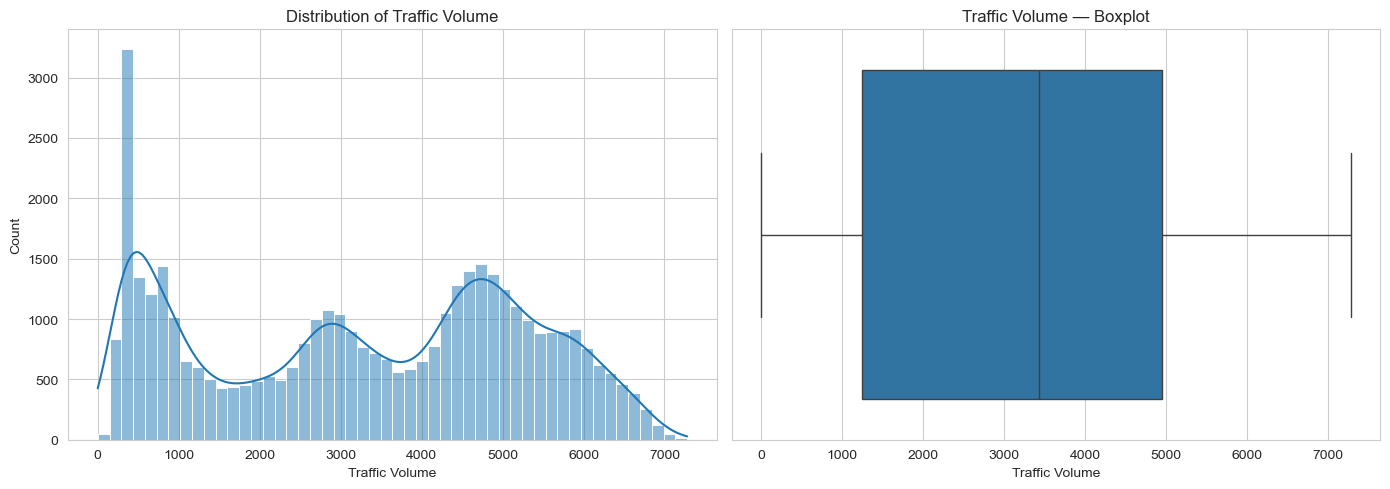

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["traffic_volume"], bins=50, kde=True, ax=ax[0])
ax[0].set_title("Distribution of Traffic Volume")
ax[0].set_xlabel("Traffic Volume")

sns.boxplot(x=df["traffic_volume"], ax=ax[1])
ax[1].set_title("Traffic Volume — Boxplot")
ax[1].set_xlabel("Traffic Volume")

plt.tight_layout()
plt.show()


### 4.2 Traffic volume over time

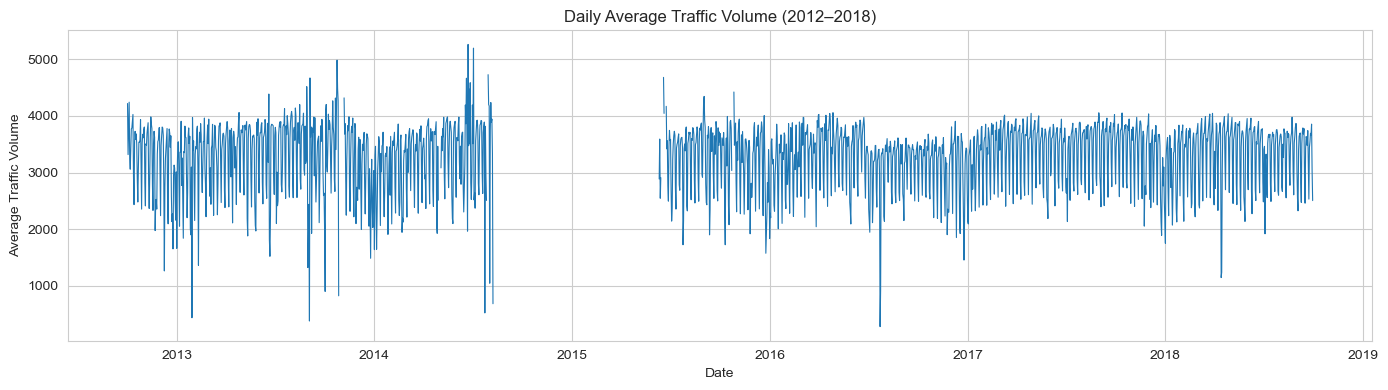

In [17]:
daily_avg = df.set_index("date_time")["traffic_volume"].resample("D").mean()

plt.figure(figsize=(14, 4))
plt.plot(daily_avg.index, daily_avg.values, linewidth=0.8)
plt.title("Daily Average Traffic Volume (2012–2018)")
plt.xlabel("Date")
plt.ylabel("Average Traffic Volume")
plt.tight_layout()
plt.show()


### 4.3 Hourly and weekly traffic patterns

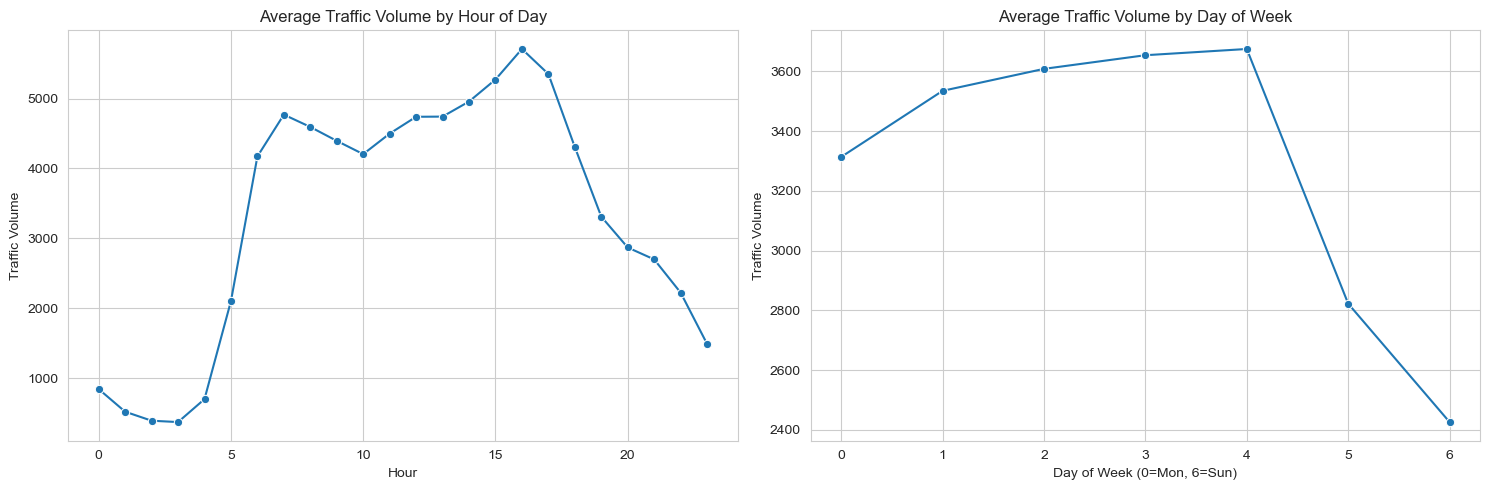

In [18]:
df["hour_tmp"] = df["date_time"].dt.hour
df["dow_tmp"] = df["date_time"].dt.dayofweek  # 0 = Monday

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(data=df, x="hour_tmp", y="traffic_volume", ax=ax[0], errorbar=None, marker="o")
ax[0].set_title("Average Traffic Volume by Hour of Day")
ax[0].set_xlabel("Hour")
ax[0].set_ylabel("Traffic Volume")

sns.lineplot(data=df, x="dow_tmp", y="traffic_volume", ax=ax[1], errorbar=None, marker="o")
ax[1].set_title("Average Traffic Volume by Day of Week")
ax[1].set_xlabel("Day of Week (0=Mon, 6=Sun)")
ax[1].set_ylabel("Traffic Volume")

plt.tight_layout()
plt.show()

df = df.drop(columns=["hour_tmp", "dow_tmp"])


Traffic volume shows a clear bimodal pattern within a day (morning and evening rush hours) and is
noticeably lower on weekends — both are strong signals for feature engineering.

### 4.4 Traffic volume by weather condition

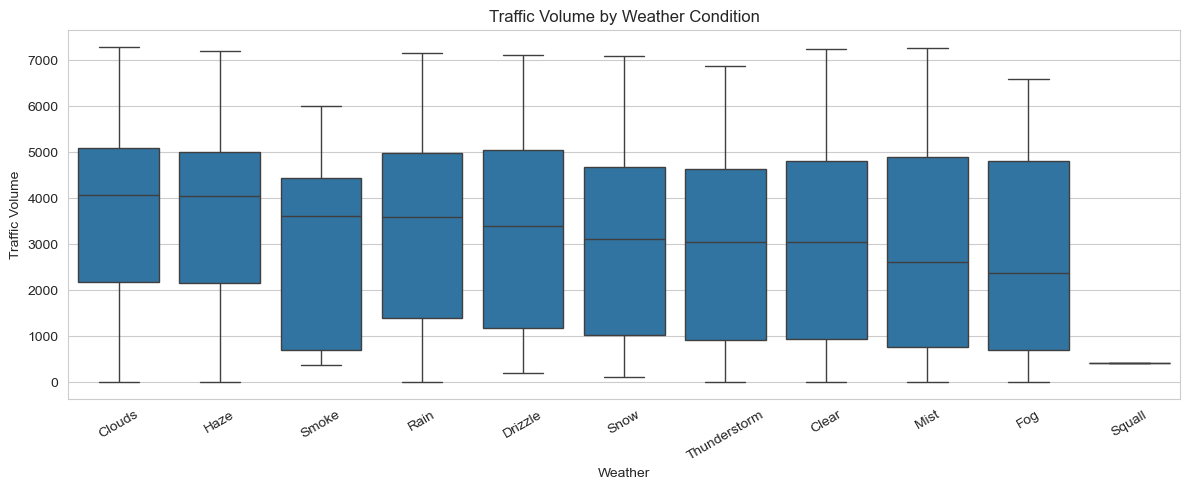

In [19]:
plt.figure(figsize=(12, 5))
order = df.groupby("weather_main")["traffic_volume"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="weather_main", y="traffic_volume", order=order)
plt.title("Traffic Volume by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Traffic Volume")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### 4.5 Traffic volume on holidays vs. regular days

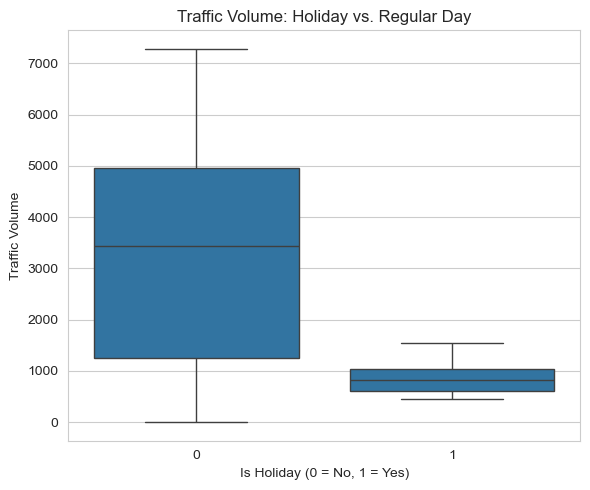

In [20]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="is_holiday", y="traffic_volume")
plt.title("Traffic Volume: Holiday vs. Regular Day")
plt.xlabel("Is Holiday (0 = No, 1 = Yes)")
plt.ylabel("Traffic Volume")
plt.tight_layout()
plt.show()


### 4.6 Correlation between numerical features

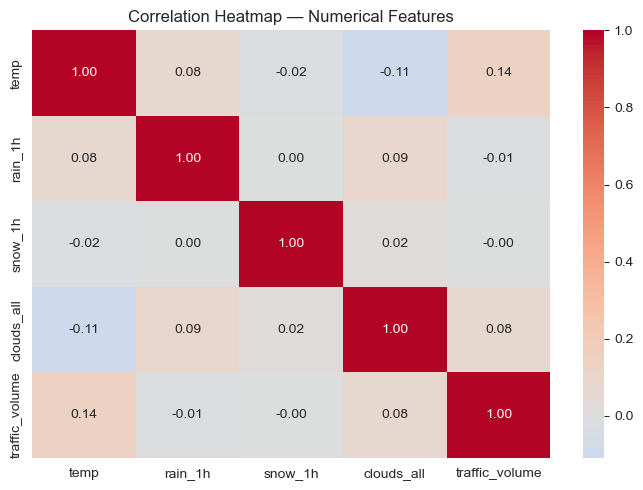

In [21]:
numeric_cols = ["temp", "rain_1h", "snow_1h", "clouds_all", "traffic_volume"]

plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Numerical Features")
plt.tight_layout()
plt.show()


**EDA takeaways:**

- Traffic volume has a strong daily (rush-hour) and weekly (weekday vs. weekend) pattern — `date_time` needs
  to be decomposed into hour, day-of-week, month, and weekend flags.
- Raw weather numerics (`temp`, `rain_1h`, `snow_1h`, `clouds_all`) have weak individual linear correlation
  with traffic volume, but `weather_main` categories show visible differences in the boxplots above.
- Holidays are associated with lower traffic volume, confirming `is_holiday` is a useful engineered feature.


## 5. Feature Engineering

### 5.1 Datetime-based features

We decompose `date_time` into components that capture the daily and weekly seasonality observed during EDA.


In [22]:
df["year"] = df["date_time"].dt.year
df["month"] = df["date_time"].dt.month
df["day"] = df["date_time"].dt.day
df["hour"] = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.dayofweek          # 0 = Monday, 6 = Sunday
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Cyclical encoding so the model understands hour 23 and hour 0 are adjacent
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df[["date_time", "year", "month", "day", "hour", "day_of_week", "is_weekend",
    "hour_sin", "hour_cos", "month_sin", "month_cos"]].head()


,date_time,year,month,day,hour,day_of_week,is_weekend,hour_sin,hour_cos,month_sin,month_cos
0,2012-10-02 09:00:00,2012,10,2,9,1,0,7.071068e-01,-0.707107,-0.866025,0.5
1,2012-10-02 10:00:00,2012,10,2,10,1,0,5.000000e-01,-0.866025,-0.866025,0.5
2,2012-10-02 11:00:00,2012,10,2,11,1,0,2.588190e-01,-0.965926,-0.866025,0.5
3,2012-10-02 12:00:00,2012,10,2,12,1,0,1.224647e-16,-1.000000,-0.866025,0.5
4,2012-10-02 13:00:00,2012,10,2,13,1,0,-2.588190e-01,-0.965926,-0.866025,0.5


### 5.2 Traffic level target for classification

We derive `traffic_level` (Low / Moderate / High) from `traffic_volume` using tercile (quantile-based)
thresholds, so each class is well represented rather than being an arbitrary fixed cut.


In [23]:
low_threshold, high_threshold = df["traffic_volume"].quantile([1/3, 2/3])
print(f"Low/Moderate threshold: {low_threshold:.0f}")
print(f"Moderate/High threshold: {high_threshold:.0f}")

def assign_traffic_level(volume):
    if volume <= low_threshold:
        return "Low"
    elif volume <= high_threshold:
        return "Moderate"
    else:
        return "High"

df["traffic_level"] = df["traffic_volume"].apply(assign_traffic_level)
df["traffic_level"].value_counts()


Low/Moderate threshold: 2274
Moderate/High threshold: 4598


traffic_level
Low         13529
Moderate    13526
High        13520
Name: count, dtype: int64

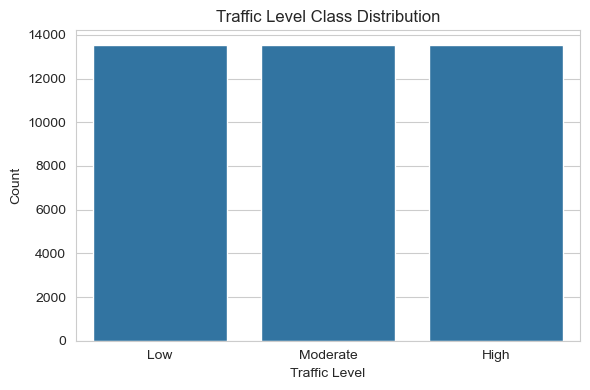

In [24]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="traffic_level", order=["Low", "Moderate", "High"])
plt.title("Traffic Level Class Distribution")
plt.xlabel("Traffic Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 6. Encoding Categorical Features

`weather_main` is a low-cardinality nominal feature, so we one-hot encode it. `weather_description` is a
higher-cardinality, more granular version of the same information and is dropped to avoid redundancy and
overfitting risk. The original `holiday` column is dropped in favor of the cleaner `is_holiday` flag.


In [25]:
print(f"weather_main categories: {df['weather_main'].nunique()}")
print(f"weather_description categories: {df['weather_description'].nunique()}")

df = pd.get_dummies(df, columns=["weather_main"], prefix="weather", drop_first=True)

# Drop redundant / already-encoded raw columns
df = df.drop(columns=["holiday", "weather_description"])

df.head()


weather_main categories: 11
weather_description categories: 36


,temp,rain_1h,snow_1h,clouds_all,date_time,traffic_volume,is_holiday,year,month,day,hour,day_of_week,is_weekend,hour_sin,hour_cos,month_sin,month_cos,traffic_level,weather_Clouds,weather_Drizzle,weather_Fog,weather_Haze,weather_Mist,weather_Rain,weather_Smoke,weather_Snow,weather_Squall,weather_Thunderstorm
0,288.28,0.0,0.0,40,2012-10-02 09:00:00,5545,0,2012,10,2,9,1,0,7.071068e-01,-0.707107,-0.866025,0.5,High,True,False,False,False,False,False,False,False,False,False
1,289.36,0.0,0.0,75,2012-10-02 10:00:00,4516,0,2012,10,2,10,1,0,5.000000e-01,-0.866025,-0.866025,0.5,Moderate,True,False,False,False,False,False,False,False,False,False
2,289.58,0.0,0.0,90,2012-10-02 11:00:00,4767,0,2012,10,2,11,1,0,2.588190e-01,-0.965926,-0.866025,0.5,High,True,False,False,False,False,False,False,False,False,False
3,290.13,0.0,0.0,90,2012-10-02 12:00:00,5026,0,2012,10,2,12,1,0,1.224647e-16,-1.000000,-0.866025,0.5,High,True,False,False,False,False,False,False,False,False,False
4,291.14,0.0,0.0,75,2012-10-02 13:00:00,4918,0,2012,10,2,13,1,0,-2.588190e-01,-0.965926,-0.866025,0.5,High,True,False,False,False,False,False,False,False,False,False


### 6.1 Encode the classification target

In [26]:
traffic_level_map = {"Low": 0, "Moderate": 1, "High": 2}
df["traffic_level_encoded"] = df["traffic_level"].map(traffic_level_map)

df[["traffic_level", "traffic_level_encoded"]].drop_duplicates().sort_values("traffic_level_encoded")


,traffic_level,traffic_level_encoded
13,Low,0
1,Moderate,1
0,High,2


## 7. Feature Scaling

Tree-based models (Random Forest, XGBoost) do not require scaled inputs, and Linear Regression's coefficients
remain interpretable without it. To keep the pipeline simple and avoid data leakage risk from scaling before
the train/test split, **scaling is deferred to the model-training notebook**, where it will be fit only on the
training split if/when needed for a specific model.


## 8. Final Dataset Overview

In [27]:
print(f"Final shape: {df.shape}")
df.info()


Final shape: (40575, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40575 entries, 0 to 40574
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   temp                   40575 non-null  float64       
 1   rain_1h                40575 non-null  float64       
 2   snow_1h                40575 non-null  float64       
 3   clouds_all             40575 non-null  int64         
 4   date_time              40575 non-null  datetime64[ns]
 5   traffic_volume         40575 non-null  int64         
 6   is_holiday             40575 non-null  int64         
 7   year                   40575 non-null  int32         
 8   month                  40575 non-null  int32         
 9   day                    40575 non-null  int32         
 10  hour                   40575 non-null  int32         
 11  day_of_week            40575 non-null  int32         
 12  is_weekend             40575 non-nu

In [28]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
temp,40575.0,281.382237,243.39,271.84,282.86,292.28,310.07,13.093825
rain_1h,40575.0,0.068791,0.0,0.0,0.0,0.0,10.09686,0.540188
snow_1h,40575.0,0.000117,0.0,0.0,0.0,0.0,0.51,0.005676
clouds_all,40575.0,44.201528,0.0,1.0,40.0,90.0,100.0,38.683697
date_time,40575,2015-12-23 22:16:28.835489792,2012-10-02 09:00:00,2014-02-02 19:30:00,2016-06-02 14:00:00,2017-08-02 23:30:00,2018-09-30 23:00:00,NaN
traffic_volume,40575.0,3290.650474,0.0,1248.5,3427.0,4952.0,7280.0,1984.772909
is_holiday,40575.0,0.001306,0.0,0.0,0.0,0.0,1.0,0.036119
year,40575.0,2015.479729,2012.0,2014.0,2016.0,2017.0,2018.0,1.888817
month,40575.0,6.489045,1.0,4.0,7.0,9.0,12.0,3.373618
day,40575.0,15.672754,1.0,8.0,16.0,23.0,31.0,8.763954


## 9. Save Cleaned Dataset

In [30]:
OUTPUT_PATH = "data/traffic_processed.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f"Cleaned dataset saved to {OUTPUT_PATH}")
print(f"Final shape: {df.shape}")


Cleaned dataset saved to data/traffic_processed.csv
Final shape: (40575, 29)


## 10. Summary

- Cleaned `holiday` into a binary `is_holiday` flag and removed the raw column.
- Removed duplicate rows and duplicate timestamps.
- Corrected invalid `temp` readings (0 K) via month-wise median imputation.
- Capped an extreme `rain_1h` outlier at the 99.9th percentile.
- Engineered `year`, `month`, `day`, `hour`, `day_of_week`, `is_weekend`, and cyclical hour/month features from `date_time`.
- Created the `traffic_level` classification target (Low / Moderate / High) using quantile-based thresholds.
- One-hot encoded `weather_main` and label-encoded `traffic_level`.
- Exported the model-ready dataset to `data/traffic_processed.csv` for use in `02_Model_Training.ipynb`.
